# Notebook 6 — Fine-Grained Emotion Over Time

Sentiment (notebook 5) collapses everything to positive/negative. This notebook decomposes mood into seven distinct emotions using a transformer trained on emotion-labeled text:

- **Joy** — happiness, celebration
- **Sadness** — grief, melancholy, longing
- **Anger** — rage, frustration
- **Fear** — anxiety, dread
- **Disgust** — revulsion
- **Surprise** — astonishment
- **Neutral** — emotionally flat

We then ask:
- Which emotions drove the sentiment decline we saw in notebook 5? More sadness? Less joy? More anger?
- Did specific emotions emerge or vanish in specific decades?
- How do emotions distribute across hip-hop vs non-hip-hop?
- Where does **love** fit? (It's not in this model — we'll handle that separately with a love classifier.)

Model: `j-hartmann/emotion-english-distilroberta-base` (~250MB).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tqdm.pandas()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
df = pd.read_parquet(PROCESSED_DIR / "songs_with_sentiment.parquet")
print(f"Loaded {len(df):,} songs")

/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loaded 6,538 songs


## Set up the emotion classifier

Same chunking strategy as notebook 5 — long lyrics get split into 512-token windows and emotion scores are averaged across chunks.

In [4]:
MODEL_ID = "j-hartmann/emotion-english-distilroberta-base"
emo_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
emo_model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)
emo_model.eval()

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
emo_model.to(device)
print(f"Device: {device}")

EMOTION_LABELS = list(emo_model.config.id2label.values())
print(f"Emotion classes: {EMOTION_LABELS}")

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Device: mps
Emotion classes: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']


In [5]:
MAX_LEN = 512
STRIDE = 256

@torch.no_grad()
def emotion_scores(text: str) -> dict:
    """Return averaged probabilities across all 512-token chunks."""
    full_ids = emo_tokenizer(text, truncation=False)["input_ids"]
    if len(full_ids) <= MAX_LEN:
        chunks = [full_ids]
    else:
        chunks = []
        for start in range(0, len(full_ids), STRIDE):
            chunk = full_ids[start : start + MAX_LEN]
            if len(chunk) < 50:
                break
            chunks.append(chunk)
    
    all_probs = []
    for ids in chunks:
        input_ids = torch.tensor([ids]).to(device)
        attn = torch.ones_like(input_ids)
        out = emo_model(input_ids=input_ids, attention_mask=attn).logits
        probs = F.softmax(out, dim=-1).cpu().numpy()[0]
        all_probs.append(probs)
    
    mean_probs = np.mean(all_probs, axis=0)
    return {label: float(mean_probs[i]) for i, label in enumerate(EMOTION_LABELS)}

# Test on one song
test_idx = df.sample(1, random_state=42).index[0]
print(f"Test: '{df.loc[test_idx, 'title']}' by {df.loc[test_idx, 'artist']}")
print(emotion_scores(df.loc[test_idx, "lyrics_text"]))

Test: 'I'll Have to Say I Love You in a Song' by Jim Croce
{'anger': 0.041104014962911606, 'disgust': 0.09998569637537003, 'fear': 0.5524461269378662, 'joy': 0.006405068561434746, 'neutral': 0.2460651993751526, 'sadness': 0.02202647179365158, 'surprise': 0.031967390328645706}


In [6]:
# Run on all songs — slowest cell, expect 10-20 minutes
emotion_data = []
for text in tqdm(df["lyrics_text"], desc="Scoring emotions"):
    emotion_data.append(emotion_scores(text))

emotion_df = pd.DataFrame(emotion_data)
for col in EMOTION_LABELS:
    df[f"emo_{col}"] = emotion_df[col].values

print(df[[f"emo_{c}" for c in EMOTION_LABELS]].describe())

Scoring emotions:   0%|          | 0/6538 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1637 > 512). Running this sequence through the model will result in indexing errors


         emo_anger  emo_disgust     emo_fear      emo_joy  emo_neutral  \
count  6538.000000  6538.000000  6538.000000  6538.000000  6538.000000   
mean      0.133869     0.065083     0.203245     0.104316     0.196334   
std       0.157384     0.083094     0.239976     0.183456     0.161214   
min       0.000682     0.000449     0.000437     0.000575     0.001434   
25%       0.023574     0.012231     0.039740     0.010719     0.063225   
50%       0.075022     0.037028     0.106357     0.029861     0.156297   
75%       0.185750     0.085916     0.265939     0.096106     0.292993   
max       0.972927     0.904652     0.992066     0.985163     0.874055   

       emo_sadness  emo_surprise  
count  6538.000000   6538.000000  
mean      0.222594      0.074559  
std       0.268123      0.123351  
min       0.001406      0.000392  
25%       0.043922      0.014958  
50%       0.095898      0.034150  
75%       0.289546      0.076325  
max       0.988921      0.977330  


## Emotion over time

For each emotion, track its mean score across all hits per year (and decade).

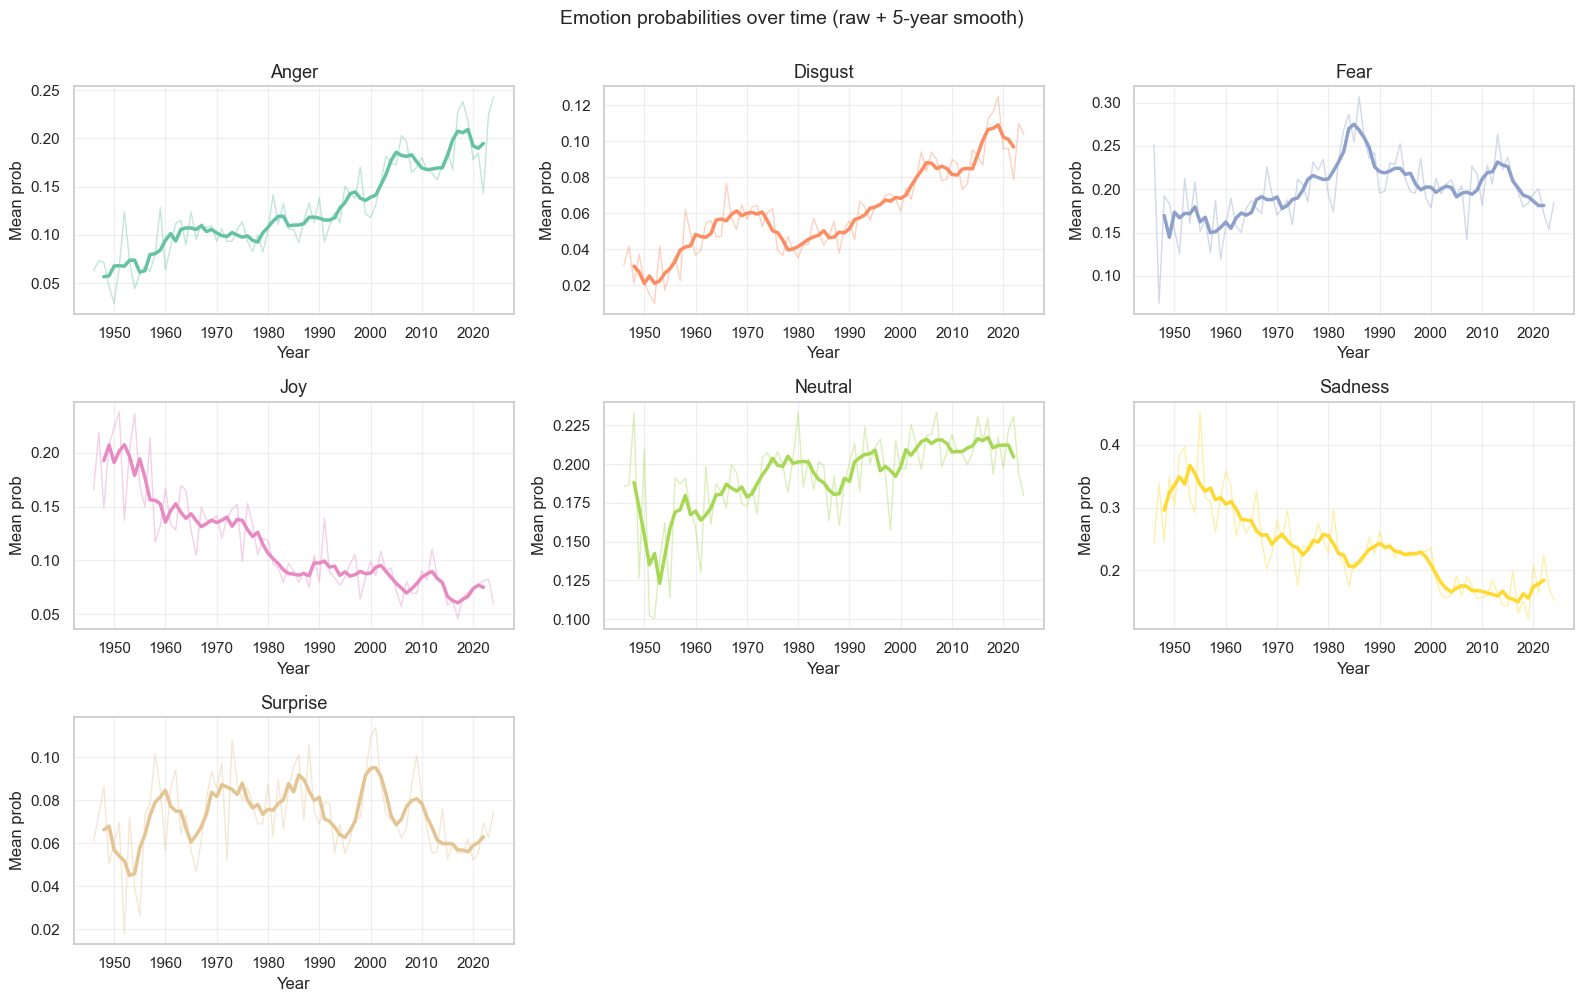


Decade-level emotion means:
        emo_anger  emo_disgust  emo_fear  emo_joy  emo_neutral  emo_sadness  \
decade                                                                        
1940        0.063        0.034     0.172    0.189        0.179        0.297   
1950        0.083        0.037     0.150    0.168        0.168        0.322   
1960        0.102        0.053     0.179    0.142        0.176        0.277   
1970        0.096        0.052     0.199    0.131        0.193        0.247   
1980        0.115        0.046     0.246    0.092        0.191        0.226   
1990        0.130        0.062     0.214    0.090        0.201        0.232   
2000        0.166        0.080     0.199    0.083        0.211        0.177   
2010        0.187        0.095     0.211    0.075        0.213        0.156   
2020        0.195        0.097     0.182    0.075        0.204        0.184   

        emo_surprise  
decade                
1940           0.066  
1950           0.073  
1960     

In [7]:
emo_cols = [f"emo_{c}" for c in EMOTION_LABELS]

# Decade-level summary
decade_emo = df.groupby("decade")[emo_cols].mean()

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()
colors = sns.color_palette("Set2", n_colors=7)
for i, label in enumerate(EMOTION_LABELS):
    ax = axes[i]
    yearly = df.groupby("year")[f"emo_{label}"].mean()
    ax.plot(yearly.index, yearly.values, color=colors[i], alpha=0.4, linewidth=1)
    ax.plot(yearly.index, yearly.rolling(5, center=True).mean(), 
            color=colors[i], linewidth=2.5)
    ax.set_title(f"{label.capitalize()}", fontsize=13)
    ax.set_xlabel("Year"); ax.set_ylabel("Mean prob")
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(EMOTION_LABELS), len(axes)):
    axes[i].axis("off")

plt.suptitle("Emotion probabilities over time (raw + 5-year smooth)", 
             fontsize=14, y=1.00)
plt.tight_layout(); plt.show()

print("\nDecade-level emotion means:")
print(decade_emo.round(3))

## What's the dominant emotion of each song?

Treat the highest-probability emotion as the song's "primary" emotion. Then ask: how has the distribution of primary emotions shifted?

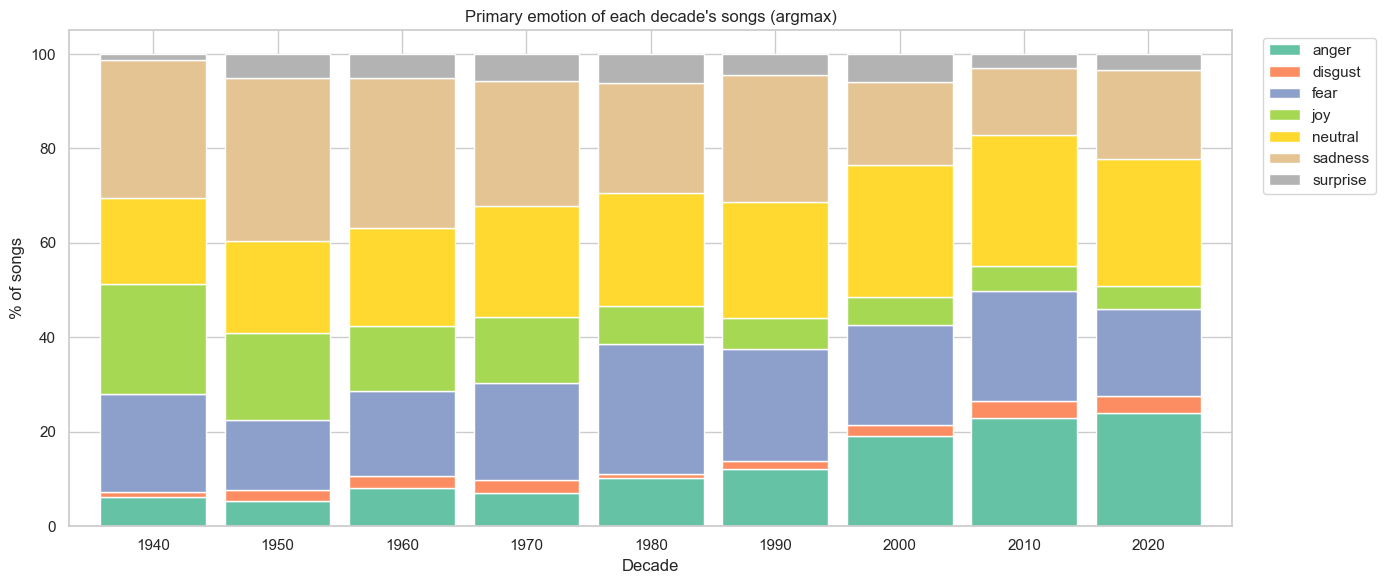

primary_emotion  anger  disgust  fear   joy  neutral  sadness  surprise
decade                                                                 
1940               6.1      1.2  20.7  23.2     18.3     29.3       1.2
1950               5.4      2.2  14.9  18.4     19.4     34.6       5.1
1960               8.1      2.5  17.9  13.9     20.7     31.7       5.0
1970               7.0      2.7  20.6  14.1     23.5     26.3       5.8
1980              10.1      1.0  27.5   8.1     23.8     23.2       6.2
1990              12.0      1.8  23.8   6.4     24.7     26.9       4.4
2000              19.0      2.4  21.2   5.9     28.0     17.5       6.0
2010              23.0      3.4  23.3   5.4     27.7     14.2       2.9
2020              24.0      3.6  18.3   5.0     26.9     18.8       3.4


In [8]:
# Argmax-based primary emotion
emotion_probs = df[emo_cols].values
primary_idx = emotion_probs.argmax(axis=1)
df["primary_emotion"] = [EMOTION_LABELS[i] for i in primary_idx]

# Per-decade distribution
decade_primary = (df.groupby(["decade", "primary_emotion"]).size()
                    .unstack(fill_value=0))
# Normalize to percentages
decade_primary_pct = decade_primary.div(decade_primary.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
decade_primary_pct.plot(kind="bar", stacked=True, ax=ax, 
                        colormap="Set2", width=0.85)
ax.set_title("Primary emotion of each decade's songs (argmax)")
ax.set_xlabel("Decade"); ax.set_ylabel("% of songs")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

print(decade_primary_pct.round(1))

## Sadness as the headline story

If the sentiment decline from notebook 5 was real, **sadness** should be the rising emotion. Check this directly.

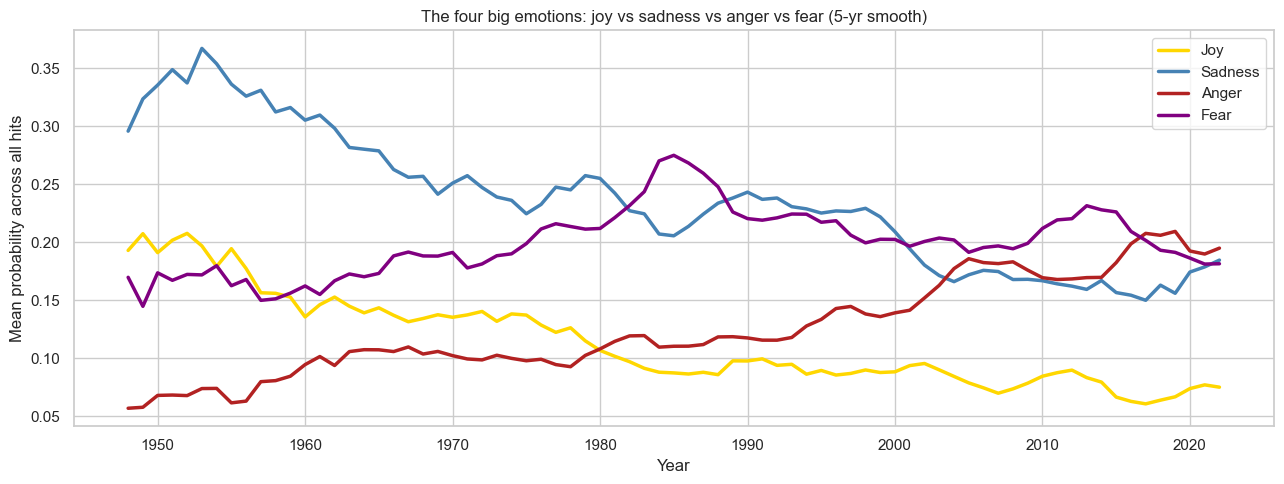

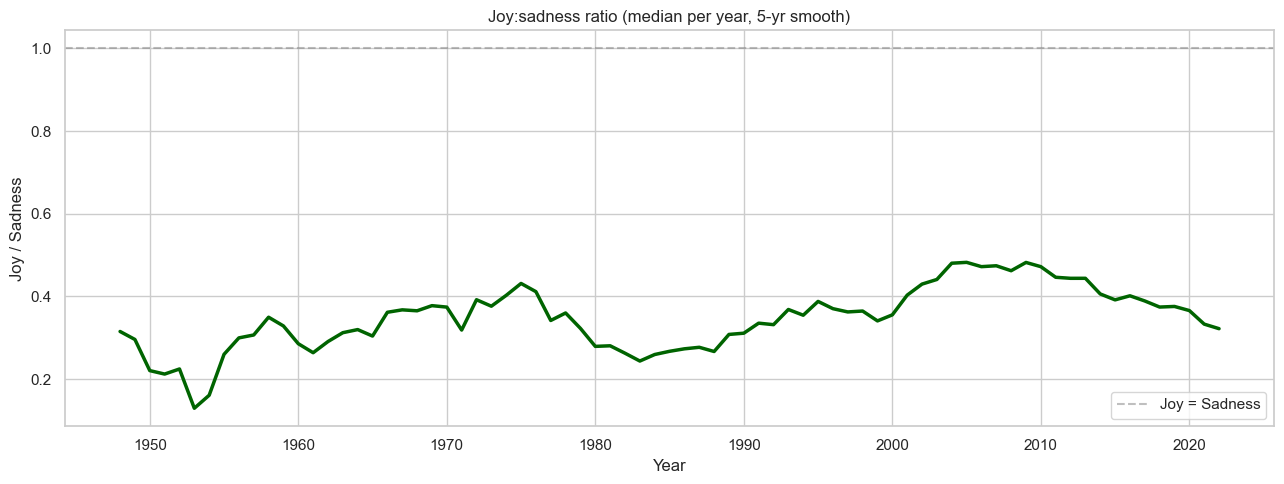

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
for label, color in [("joy", "gold"), ("sadness", "steelblue"), 
                       ("anger", "firebrick"), ("fear", "purple")]:
    yearly = df.groupby("year")[f"emo_{label}"].mean()
    ax.plot(yearly.index, yearly.rolling(5, center=True).mean(),
            color=color, linewidth=2.5, label=label.capitalize())
ax.set_title("The four big emotions: joy vs sadness vs anger vs fear (5-yr smooth)")
ax.set_xlabel("Year"); ax.set_ylabel("Mean probability across all hits")
ax.legend()
plt.tight_layout(); plt.show()

# Joy:sadness ratio
df["joy_sadness_ratio"] = df["emo_joy"] / (df["emo_sadness"] + 1e-6)
yearly_ratio = df.groupby("year")["joy_sadness_ratio"].median()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(yearly_ratio.index, yearly_ratio.rolling(5, center=True).mean(),
        color="darkgreen", linewidth=2.5)
ax.axhline(1, color="gray", linestyle="--", alpha=0.5, label="Joy = Sadness")
ax.set_title("Joy:sadness ratio (median per year, 5-yr smooth)")
ax.set_xlabel("Year"); ax.set_ylabel("Joy / Sadness")
ax.legend()
plt.tight_layout(); plt.show()

## Genre split: which genre uses which emotions?

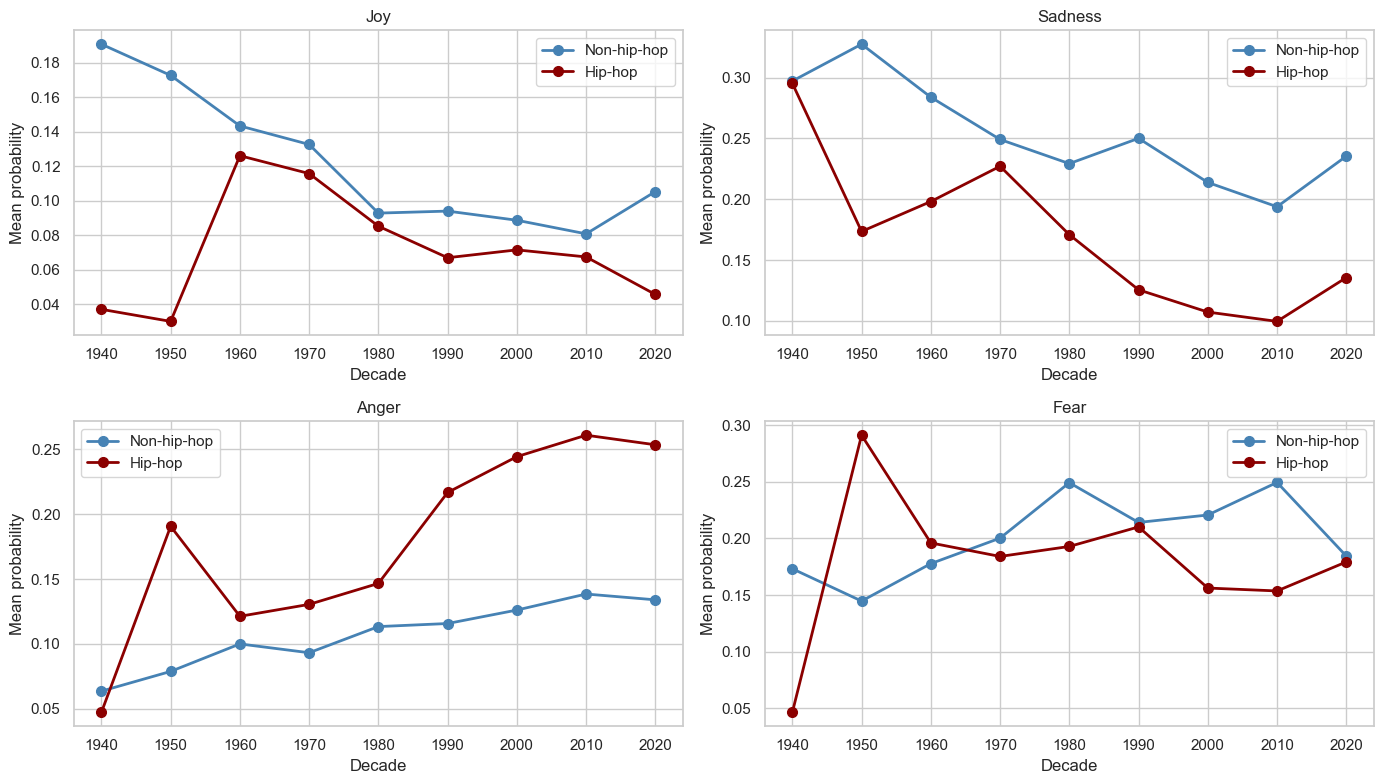

In [10]:
HIPHOP_MARKERS = {
    "tryna", "gon", "i'ma", "imma", "ain't", "nah", "bout", "lemme", "finna",
    "lil", "ayy", "yuh", "huh", "nigga", "niggas", "homie", "shawty",
    "bitch", "bitches", "shit", "fuck", "fuckin", "fucking",
}
df["hh_count"] = df["tokens"].apply(
    lambda toks: sum(1 for t in toks if t in HIPHOP_MARKERS)
)
df["is_hiphop"] = df["hh_count"] / df["n_tokens"] >= 0.01

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, label in enumerate(["joy", "sadness", "anger", "fear"]):
    ax = axes[i]
    for is_hh, color, name in [(False, "steelblue", "Non-hip-hop"),
                                 (True, "darkred", "Hip-hop")]:
        sub = df[df["is_hiphop"] == is_hh]
        dec = sub.groupby("decade")[f"emo_{label}"].mean()
        ax.plot(dec.index, dec.values, "o-", color=color, linewidth=2, 
                markersize=7, label=name)
    ax.set_title(label.capitalize())
    ax.set_xlabel("Decade"); ax.set_ylabel("Mean probability")
    ax.legend()
plt.tight_layout(); plt.show()

In [11]:
# Save augmented data
df.to_parquet(PROCESSED_DIR / "songs_with_emotions.parquet")
print(f"Saved {len(df):,} songs with emotion scores")

Saved 6,538 songs with emotion scores
